In [ ]:
from Dataset import TrajDataset
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from DDBSCAN import Raster_DBSCAN
import numpy as np
import matplotlib.colors as mcolors
import torch
from Utils import get_trajs_from_Kalman_out
# times new roman font
plt.rcParams["font.family"] = "Times New Roman"
seed = 414
# np.random.seed(seed)
colors = np.random.rand(600, 3)
colors = np.concatenate([np.array([[0,0,0]]),colors],axis = 0)
colormap = mcolors.ListedColormap(colors)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
batch_size = 8
time_span = 100
val_dataset = TrajDataset(r"D:\TimeSpaceDiagramDataset\EncoderDecoder_EvenlySampled_FreeflowAug_0914_5res_lanechange_signal\100_frame\val",time_span)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

In [14]:
for batch in tqdm(val_loader):    
    break


  0%|          | 0/30750 [00:00<?, ?it/s]


In [16]:
batch.shape

torch.Size([8, 200, 100])

In [4]:
lane_unit_num = 200
db = Raster_DBSCAN(Td_map_szie=(lane_unit_num,time_span), window_size=[5,5],eps = 1,min_samples=1)


In [ ]:
target_numpy = target.numpy()
for batch in range(batch_size):
    trajs = get_trajs_from_Kalman_out(Labels,max_prediction_count = 2)
    
    break

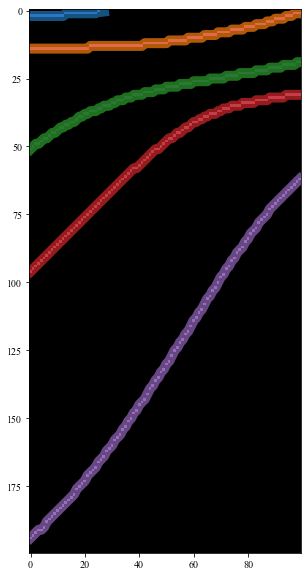

In [15]:
plt.figure(figsize=(20, 10))
plt.imshow(Labels, cmap= colormap, interpolation='none')
for i,traj in enumerate(trajs):
    t, x = zip(*traj)
    plt.plot(t,x,label = f'pred_{i}', linewidth = 10,alpha = 0.7)
plt.show()

In [95]:
import torch
import torch.nn as nn
class TrajectoryLSTM(nn.Module):
    def __init__(self, hidden_size=64, num_layers=2, dropout=0.2):
        """
        LSTM model for trajectory prediction
        
        Args:
            hidden_size: Number of features in hidden state
            num_layers: Number of recurrent layers
            dropout: Dropout rate
        """
        super(TrajectoryLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=1,          # One feature (position)
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Output layer
        self.fc = nn.Linear(hidden_size, 1)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.to(self.device)
    
    def forward(self, x, mask):
        """
        Forward pass with handling of occlusions
        
        Args:
            x: Input tensor [batch_size, sequence_length]
            mask: Boolean mask indicating non-occluded positions [batch_size, sequence_length]
        """
        batch_size = x.size(0)
        
        # Reshape for LSTM input [batch_size, sequence_length, input_size]
        x = x.unsqueeze(-1)
        
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        
        # Handle occlusions by using packed sequences
        lengths = mask.sum(dim=1).cpu()
        
        # If all sequences have at least one visible frame
        if torch.all(lengths > 0):
            # Create packed sequence to handle variable length
            packed_x = nn.utils.rnn.pack_padded_sequence(
                x, lengths, batch_first=True, enforce_sorted=False
            )
            
            # Run through LSTM
            packed_output, (h_n, _) = self.lstm(packed_x, (h0, c0))
            
            # Unpack output
            output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
            
            # Get the last non-padded output for each sequence
            idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, self.hidden_size).to(x.device)
            last_output = output.gather(1, idx).squeeze(1)
        else:
            # Handle edge case where all frames might be occluded
            # Use the last hidden state directly
            _, (h_n, _) = self.lstm(x, (h0, c0))
            last_output = h_n[-1]
        
        # Predict next position
        pred = self.fc(last_output)
        
        return pred

In [96]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  
model = TrajectoryLSTM().to(device)


In [97]:
x = torch.from_numpy(trajs[1][:10,1]).unsqueeze(0).to(device).float()
mask = torch.ones_like(x).bool().to(device)
# randomly occlude 20% of the data
occlusion_rate = 0.2
num_occluded = int(x.size(1) * occlusion_rate)
indices = torch.randperm(x.size(1))[:num_occluded]
mask[0, indices] = False
pred = model(x, mask)
pred = pred.squeeze(0).cpu().detach().numpy()

In [98]:
mask.sum(dim=1).cpu()

tensor([8])

In [99]:
packed_x = nn.utils.rnn.pack_padded_sequence(
                x, lengths = mask.sum(dim=1).cpu(), batch_first=True, enforce_sorted=False
            )

In [100]:
x

tensor([[14., 14., 14., 14., 14., 14., 14., 14., 14., 14.]], device='cuda:0')

In [101]:
packed_x

PackedSequence(data=tensor([14., 14., 14., 14., 14., 14., 14., 14.], device='cuda:0'), batch_sizes=tensor([1, 1, 1, 1, 1, 1, 1, 1]), sorted_indices=tensor([0], device='cuda:0'), unsorted_indices=tensor([0], device='cuda:0'))

In [56]:
mask

tensor([[ True,  True,  True,  True,  True,  True, False,  True, False,  True]],
       device='cuda:0')

In [54]:
pred

array([-0.02312001], dtype=float32)

In [55]:
model(x,mask)

tensor([[-0.0286]], device='cuda:0', grad_fn=<AddmmBackward0>)